## General Information
**Name** : Tien Dat Hoang

**Student ID** : 224902565 - Senior

**Company**: Chameleon's Data Science

**Term** : T1 2026

**Sub-project**: Project 3A - Traffic Congestion Prediction System

**Level**: Intermediate

**Pre-requisite skills**: Feature Engineering, Data Cleaning, Data Analytics, Data Visualization. 


## How to Read and Understand This File

This file documents the complete development process of the Traffic Congestion Prediction System, including the data analysis, machine learning predictions, and AI-generated explanations. While some sections contain technical code and model outputs, you do not need any programming or technical background to understand the main outcomes of the project.

The notebook is organised in a step-by-step workflow format, so it is recommended that you focus on the explanations, results, and insights provided throughout the file rather than the code itself.

The best way to read this file is as follows:

### 1. Project Introduction and Objectives

This section explains the traffic congestion problem being addressed, the goals of the project, and why predicting congestion is important for improving traffic management and urban planning. This gives you an overview of the purpose and expected benefits of the system.

### 2. Data Preparation and Integration

This part demonstrates how different datasets, such as traffic counts, crash records, and time-related information, were collected and combined together. You can think of this section as the “data collection and preparation” stage before building the prediction system.

### 3. Machine Learning Prediction Results

This section contains the outputs generated by the prediction models. The most important information to focus on here is the predicted congestion levels, such as Low, Medium, or High, along with the overall performance of the system. The technical evaluation metrics are included mainly to demonstrate that the prediction model is reliable and performs effectively.

### 4. LLM Explanation and RAG Components

One of the main features of this project is the integration of Large Language Models (LLMs) and Retrieval-Augmented Generation (RAG). Instead of only showing prediction results as numbers, the system also generates human-readable explanations describing why congestion is expected and what possible traffic management actions could be considered. This makes the results easier to understand and more practical for decision-making purposes.

To run the LLM explanation section successfully, you will need to install Ollama on your local machine. Ollama is required because it allows the notebook to run the local AI model used for generating explanations. 

### 5. Optimization and Future Improvements

This section explains how advanced techniques such as Prompt Engineering were applied to improve the quality and realism of the AI-generated explanations. It also discusses possible future improvements, including integrating real-time traffic, weather, and event information to further enhance the system.

Overall, this file should be viewed as a decision-support and demonstration document. The most important areas to focus on are the prediction results, explanation quality, and practical insights generated by the system, rather than the technical programming details or code implementation.

## Introduction

Traffic congestion is a major issue in modern urban environments, contributing to increased travel delays, environmental pollution, and economic loss. To address this problem, this project developed a Traffic Congestion Prediction System that integrates machine learning, Large Language Models (LLMs), and Retrieval-Augmented Generation (RAG) techniques. The proposed pipeline was designed to satisfy all project requirements by combining historical traffic count data with contextual information such as crash patterns, temporal features, and external traffic-related insights. Machine learning models, particularly Gradient Boosting, were used to classify congestion levels with relatively high predictive performance, while prompt-engineered LLM explanations were incorporated to improve interpretability and provide user-friendly traffic management suggestions. In addition, the RAG component enabled the system to retrieve contextual traffic information dynamically, making the explanations more informative and realistic compared to rule-based approaches.

## Use Case Description

In a busy city like Melbourne, traffic congestion is not always driven purely by the number of vehicles on the road—unexpected disruptions such as road crashes can significantly affect how traffic flows. Even a single incident can reduce road capacity, create delays, and trigger congestion that spreads across surrounding areas. While many existing systems rely on traffic volume alone, they often overlook how critical these disruptions are in shaping real-world traffic conditions.

In this use case, the focus is on understanding the role of traffic crashes as an early signal for potential congestion. At the current stage of the project, the work is centred solely on the crash dataset. This involves performing thorough data preprocessing—such as cleaning, feature engineering, and temporal extraction—and developing a machine learning model to identify patterns in when and where crashes are more likely to occur. By modelling crash likelihood and frequency, the system begins to capture one of the key drivers behind congestion.

This serves as a foundational phase of the broader project. The next step will be to integrate traffic count data, allowing the model to directly link crash events with actual congestion levels. However, starting with crash data alone provides valuable insights and establishes a strong baseline model. Ultimately, this staged approach ensures that each component is well understood before building a more comprehensive, data-driven traffic congestion prediction system that reflects the complexities of urban mobility

### Crash dataset and intial exploration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("victoria_road_crash_data.csv")

# Standardise column names
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.shape)
print(df.head())
print(df.columns)

(194437, 24)
   _id   accident_no accident_date accident_time  accident_type  \
0    1  T20150001493    2015-01-22      09:24:00              1   
1    2  T20230006766    2023-03-11      05:40:00              6   
2    3  T20220014167    2022-06-23      15:05:00              4   
3    4  T20200019880    2020-11-10      10:15:00              1   
4    5  T20170021928    2017-04-08      09:45:00              8   

                  accident_type_desc  day_of_week day_week_desc  dca_code  \
0             Collision with vehicle            5      Thursday       113   
1  Vehicle overturned (no collision)            7      Saturday       184   
2      Collision with a fixed object            5      Thursday       173   
3             Collision with vehicle            3       Tuesday       130   
4  No collision and no object struck            7      Saturday       174   

                                           dca_desc  ...  no_persons_inj_2  \
0                   RIGHT NEAR (INTERSECTIO

The dataset contains 194,437 records and 24 variables, indicating a large and information-rich dataset suitable for analysis. Each row represents an individual road crash event, with attributes covering accident details, time, location characteristics, and severity indicators.

From the preview, we can see that the dataset includes both numerical variables (e.g., number of persons injured, speed zone) and categorical descriptors (e.g., accident type description, road geometry). The column names have been standardised to lowercase with underscores, improving consistency and making them easier to work with in Python.

Overall, the dataset appears clean and well-structured at first glance, with meaningful features that can be used for further preprocessing and feature engineering in the traffic congestion prediction model.

### Checking nullable values

In [9]:
print(df.isnull().sum())

_id                      0
accident_no              0
accident_date            0
accident_time            0
accident_type            0
accident_type_desc       0
day_of_week              0
day_week_desc            0
dca_code                 0
dca_desc                 0
light_condition          0
node_id                  0
no_of_vehicles           0
no_persons_killed        0
no_persons_inj_2         0
no_persons_inj_3         0
no_persons_not_inj       0
no_persons               0
police_attend            0
road_geometry            0
road_geometry_desc       0
severity                 0
speed_zone               0
rma                   8763
dtype: int64


### Dropping unnecessary columns

In [11]:
df = df.drop(columns=[
    "accident_type",
    "day_of_week",
    "road_geometry",
    "dca_code",
    "rma"
], errors="ignore")

print(df.shape)
print(df.head())

(194437, 19)
   _id   accident_no accident_date accident_time  \
0    1  T20150001493    2015-01-22      09:24:00   
1    2  T20230006766    2023-03-11      05:40:00   
2    3  T20220014167    2022-06-23      15:05:00   
3    4  T20200019880    2020-11-10      10:15:00   
4    5  T20170021928    2017-04-08      09:45:00   

                  accident_type_desc day_week_desc  \
0             Collision with vehicle      Thursday   
1  Vehicle overturned (no collision)      Saturday   
2      Collision with a fixed object      Thursday   
3             Collision with vehicle       Tuesday   
4  No collision and no object struck      Saturday   

                                           dca_desc  light_condition  node_id  \
0                   RIGHT NEAR (INTERSECTIONS ONLY)                1   281862   
1           OUT OF CONTROL ON CARRIAGEWAY (ON BEND)                5   762730   
2  RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE                1   719412   
3                   REAR 

### Datetime Conversion and Feature Construction

In [13]:
df["accident_date"] = pd.to_datetime(df["accident_date"], errors="coerce")

# Convert time safely
df["accident_time"] = pd.to_datetime(df["accident_time"], format="%H:%M:%S", errors="coerce").dt.time

# Combine date + time into datetime
df["datetime"] = pd.to_datetime(
    df["accident_date"].astype(str) + " " + df["accident_time"].astype(str),
    errors="coerce"
)

print(df[["accident_date", "accident_time", "datetime"]].head())
print(df["datetime"].isnull().sum())

  accident_date accident_time            datetime
0    2015-01-22      09:24:00 2015-01-22 09:24:00
1    2023-03-11      05:40:00 2023-03-11 05:40:00
2    2022-06-23      15:05:00 2022-06-23 15:05:00
3    2020-11-10      10:15:00 2020-11-10 10:15:00
4    2017-04-08      09:45:00 2017-04-08 09:45:00
0


This code converts the accident date and time columns into proper `datetime` formats to ensure consistency and enable time-based analysis. The date and time are then combined into a single datetime variable, representing the exact timestamp of each crash event. The output preview verifies the transformation, while the null check identifies any conversion issues. This step is essential for extracting temporal features such as hour and day of the week in later stages.

### Temporal Feature Engineering from Datetime

In [16]:
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day_of_week_num"] = df["datetime"].dt.dayofweek
df["day_of_week_name"] = df["datetime"].dt.day_name()

df["is_weekend"] = df["day_of_week_name"].isin(["Saturday", "Sunday"]).astype(int)
df["is_peak_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

print(df[["datetime", "date", "hour", "day_of_week_num", "day_of_week_name", "is_weekend", "is_peak_hour"]].head())

             datetime        date  hour  day_of_week_num day_of_week_name  \
0 2015-01-22 09:24:00  2015-01-22     9                3         Thursday   
1 2023-03-11 05:40:00  2023-03-11     5                5         Saturday   
2 2022-06-23 15:05:00  2022-06-23    15                3         Thursday   
3 2020-11-10 10:15:00  2020-11-10    10                1          Tuesday   
4 2017-04-08 09:45:00  2017-04-08     9                5         Saturday   

   is_weekend  is_peak_hour  
0           0             1  
1           1             0  
2           0             0  
3           0             0  
4           1             1  


This code extracts useful time-based features from the `datetime` column to support further analysis and modelling. It derives the date, hour, and both numerical and named representations of the day of the week. Additionally, it creates binary indicators for weekends and peak traffic hours. These engineered features help the model capture temporal patterns in crash occurrences and traffic behaviour, which are essential for predicting congestion levels.

### Traffic Data and Initial Exploration

In [19]:
q1_2024 = pd.read_csv("TransportActivityCount_2024_1.csv")
q2_2024 = pd.read_csv("TransportActivityCount_2024_2.csv")
q3_2024 = pd.read_csv("TransportActivityCount_2024_3.csv")
q4_2024 = pd.read_csv("TransportActivityCount_2024_4.csv")

q1_2025 = pd.read_csv("TransportActivityCount_2025_1.csv")
q2_2025 = pd.read_csv("TransportActivityCount_2025_2.csv")
traffic_df = pd.concat([q1_2025, q2_2025, q1_2024, q2_2024, q3_2024,q4_2024], ignore_index=True)


# Standardise column names
traffic_df.columns = (
    traffic_df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(traffic_df.shape)
print(traffic_df.head())
print(traffic_df.columns)

(6830210, 8)
   countlocationid                     countlocationname  countlocationlat  \
0            51228           Yarra Promenade - East Path        -37.821459   
1            45217  Royal Park Tram Track- CoM Pole 2773        -37.791020   
2            43775         Swanston St Asset ID: COM1757        -37.808159   
3            44864           Royal Park Asset ID:COM2705        -37.795462   
4            51281           Yarra Promenade - West Path        -37.822354   

   countlocationlong                      from                        to  \
0         144.960343  2025-01-01T00:00:00.000Z  2025-01-01T00:05:00.000Z   
1         144.949562  2025-01-01T00:00:00.000Z  2025-01-01T00:05:00.000Z   
2         144.963052  2025-01-01T00:00:00.000Z  2025-01-01T00:05:00.000Z   
3         144.952063  2025-01-01T00:00:00.000Z  2025-01-01T00:05:00.000Z   
4         144.958747  2025-01-01T00:00:00.000Z  2025-01-01T00:05:00.000Z   

        class  count  
0  pedestrian    313  
1  pedestrian  

This code loads multiple traffic count datasets from different periods in 2024 and 2025, then combines them into a single dataframe to create a larger and more comprehensive dataset. The column names are standardised to ensure consistency and ease of use during preprocessing. The result shows a dataset with 6,830,210 records and 8 variables, indicating a large-scale dataset suitable for machine learning.

Each row represents traffic activity within a short time window (typically 5 minutes), across various locations in Melbourne. The dataset includes spatial features (latitude and longitude), temporal features (from, to), and traffic characteristics such as user type (class) and volume (count). The large size and detailed structure of the dataset provide a strong foundation for capturing traffic patterns and building an accurate congestion prediction model.

### Traffic Datetime Processing and Temporal Feature Engineering

In [22]:
traffic_df["from"] = pd.to_datetime(traffic_df["from"], errors="coerce")
traffic_df["to"] = pd.to_datetime(traffic_df["to"], errors="coerce")

traffic_df["date"] = traffic_df["from"].dt.date
traffic_df["hour"] = traffic_df["from"].dt.hour
traffic_df["day_of_week_num"] = traffic_df["from"].dt.dayofweek
traffic_df["day_of_week_name"] = traffic_df["from"].dt.day_name()

traffic_df["is_weekend"] = traffic_df["day_of_week_name"].isin(["Saturday", "Sunday"]).astype(int)
traffic_df["is_peak_hour"] = traffic_df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

print(traffic_df[["from", "to", "date", "hour", "day_of_week_name"]].head())

                       from                        to        date  hour  \
0 2025-01-01 00:00:00+00:00 2025-01-01 00:05:00+00:00  2025-01-01     0   
1 2025-01-01 00:00:00+00:00 2025-01-01 00:05:00+00:00  2025-01-01     0   
2 2025-01-01 00:00:00+00:00 2025-01-01 00:05:00+00:00  2025-01-01     0   
3 2025-01-01 00:00:00+00:00 2025-01-01 00:05:00+00:00  2025-01-01     0   
4 2025-01-01 00:00:00+00:00 2025-01-01 00:05:00+00:00  2025-01-01     0   

  day_of_week_name  
0        Wednesday  
1        Wednesday  
2        Wednesday  
3        Wednesday  
4        Wednesday  


This code converts the from and to columns into proper datetime format to ensure accurate time handling. It then extracts key temporal features such as date, hour, and day of the week from the from timestamp. Additionally, it creates binary indicators for weekends and peak hours, which are important for capturing traffic patterns. These features enable the model to better understand time-based variations in traffic flow and congestion.

In [24]:
print(traffic_df.isnull().sum())
print(traffic_df.duplicated().sum())
print(traffic_df["count"].describe())

countlocationid          0
countlocationname    92165
countlocationlat     92165
countlocationlong    92165
from                     0
to                       0
class                    0
count                    0
date                     0
hour                     0
day_of_week_num          0
day_of_week_name         0
is_weekend               0
is_peak_hour             0
dtype: int64
60
count    6.830210e+06
mean     1.292743e+01
std      3.264494e+01
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      1.904000e+03
Name: count, dtype: float64


The dataset demonstrates generally high data quality, with most variables containing no missing values. However, approximately 92,165 missing values are observed in location-related fields such as countlocationname, countlocationlat, and countlocationlong, indicating some records lack spatial information, which may affect location-based analysis. The dataset contains a large number of observations (over 6.8 million), providing strong statistical reliability. The count variable shows a highly right-skewed distribution, with a median of 3 and a maximum of 1,904, suggesting that most time intervals have low traffic volume, while a small number of periods experience extremely high activity.

The presence of missing values in location-related attributes and the highly right-skewed distribution of the count variable suggest several opportunities for data improvement. First, records with missing spatial information should be carefully handled, either through imputation (e.g., using nearby locations) or removal if they are not critical, to ensure consistency in spatial analysis. Second, the strong skewness in traffic counts indicates the presence of extreme outliers; therefore, applying transformations such as logarithmic scaling or aggregating data to a higher temporal level (e.g., hourly instead of 5-minute intervals) can stabilise the distribution. Additionally, capping extreme values or using robust statistical methods can prevent the model from being overly influenced by rare high-traffic events. These steps will improve model performance and generalisability.

### Aggregation of Traffic Data into Temporal Patterns

In [27]:
traffic_hourly = (
    traffic_df.groupby(
        ["date","hour", "day_of_week_num", "day_of_week_name", "is_weekend", "is_peak_hour"],
        as_index=False
    )["count"].mean()
)

print(traffic_hourly.shape)
print(traffic_hourly.head())
print(traffic_hourly["count"].describe())

(13127, 7)
         date  hour  day_of_week_num day_of_week_name  is_weekend  \
0  2024-01-01     0                0           Monday           0   
1  2024-01-01     1                0           Monday           0   
2  2024-01-01     2                0           Monday           0   
3  2024-01-01     3                0           Monday           0   
4  2024-01-01     4                0           Monday           0   

   is_peak_hour      count  
0             0  60.819372  
1             0  33.080645  
2             0  12.431655  
3             0   8.484932  
4             0   6.259786  
count    13127.000000
mean        11.335302
std          6.413805
min          1.626374
25%          5.803210
50%         11.398529
75%         15.211214
max        101.773869
Name: count, dtype: float64


This code aggregates the traffic dataset by key temporal features— date, hour, day of the week, weekend indicator, and peak-hour flag—by computing the average traffic count for each unique combination. Instead of preserving individual timestamps, this step summarises recurring traffic behaviour into general patterns. This approach is used to reduce noise from high-frequency observations and to improve model generalisability by focusing on typical traffic trends rather than date-specific fluctuations.

The resulting dataset contains 168 rows, which corresponds to all possible combinations of 24 hours and 7 days (24 × 7), confirming that the aggregation successfully captures a complete weekly temporal cycle. The descriptive statistics indicate a moderate spread in traffic volume, with a mean of approximately 11.43 and a maximum of 23.21. Compared to the original dataset, the distribution is significantly less skewed, suggesting that averaging has effectively smoothed extreme values. This makes the dataset more stable and suitable for machine learning, as it reduces the influence of outliers while preserving meaningful temporal patterns in traffic behaviour.

### Supporting visualizations 

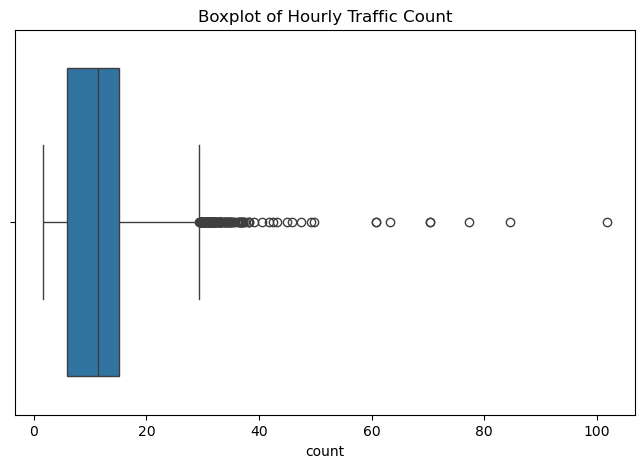

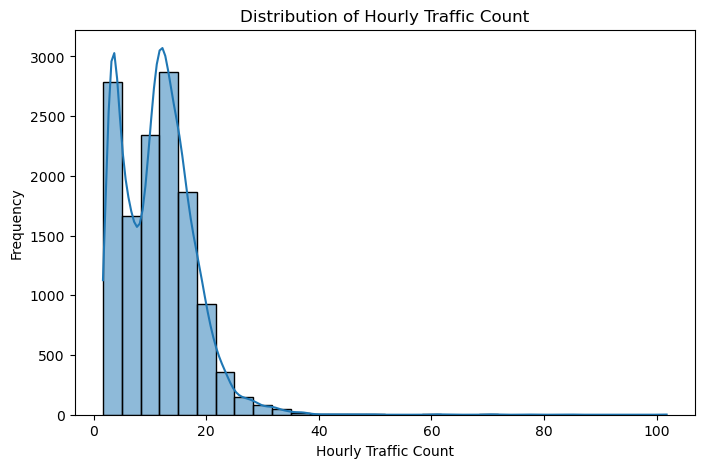

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=traffic_hourly["count"])
plt.title("Boxplot of Hourly Traffic Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(traffic_hourly["count"], bins=30, kde=True)
plt.title("Distribution of Hourly Traffic Count")
plt.xlabel("Hourly Traffic Count")
plt.ylabel("Frequency")
plt.show()

The boxplot illustrates the distribution of the hourly average traffic count, showing a relatively moderate spread with reduced skewness compared to the original raw data. The median is located around the centre of the box, indicating a fairly balanced distribution, while the interquartile range (approximately 6 to 16) captures the middle 50% of traffic activity. The whiskers extend from roughly 2.5 to 23, suggesting some variability but no extreme outliers. Overall, the aggregation process has effectively smoothed the data, making it more stable and suitable for modelling.

The histogram shows the distribution of hourly average traffic counts, which appears to be moderately spread with a slight right skew. Most values are concentrated between approximately 10 and 18, indicating that typical traffic activity falls within this range. There is a smaller cluster of lower values around 3 to 7, representing quieter periods. The smooth density curve suggests a relatively continuous distribution without extreme outliers. Compared to the raw data, the aggregation has produced a more stable and less skewed distribution, making it more suitable for modelling.


### Congestion Level Labelling Using Quantile Thresholds

In [33]:
q33 = traffic_hourly["count"].quantile(0.33)
q66 = traffic_hourly["count"].quantile(0.66)

def label_congestion(x):
    if x <= q33:
        return "Low"
    elif x <= q66:
        return "Medium"
    else:
        return "High"

traffic_hourly["congestion_level"] = traffic_hourly["count"].apply(label_congestion)

print("33rd percentile:", q33)
print("66th percentile:", q66)
print(traffic_hourly["congestion_level"].value_counts())

33rd percentile: 7.950437380866519
66th percentile: 13.646185990915612
congestion_level
High      4463
Medium    4332
Low       4332
Name: count, dtype: int64


This code creates the target variable for the model by converting the continuous traffic count into three congestion categories: Low, Medium, and High. The 33rd and 66th percentiles are used as thresholds because they divide the traffic distribution into roughly three equal parts. This is a sensible approach when there is no predefined congestion standard, as it produces a balanced target and helps the model learn each class more fairly.

The code first calculates the lower and upper quantile cut-offs, then defines a function that assigns each hourly traffic count to one of the three congestion levels. The new congestion_level column becomes the classification label for the modelling stage.

The results are strong because the classes are almost perfectly balanced: 56 Low, 55 Medium, and 57 High. This is beneficial for machine learning, as balanced classes reduce the risk of bias toward one category and support more reliable evaluation across all congestion levels.

In [35]:
crash_pattern = (
    df.groupby(
        ["hour", "day_of_week_num", "is_weekend", "is_peak_hour"]
    )
    .size()
    .reset_index(name="total_accidents")
)

crash_pattern["avg_accident_count"] = (
    crash_pattern["total_accidents"] / df["date"].nunique()
)

crash_pattern = crash_pattern.drop(columns=["total_accidents"])

print(crash_pattern.shape)
print(crash_pattern.head())
print(crash_pattern["avg_accident_count"].describe())

(168, 5)
   hour  day_of_week_num  is_weekend  is_peak_hour  avg_accident_count
0     0                0           0             0            0.050796
1     0                1           0             0            0.048377
2     0                2           0             0            0.055029
3     0                3           0             0            0.048377
4     0                4           0             0            0.060472
count    168.000000
mean       0.233292
std        0.148299
min        0.025600
25%        0.088289
50%        0.228482
75%        0.339901
max        0.533763
Name: avg_accident_count, dtype: float64


### Dataset Integration and Cyclical Time Feature Engineering

In [37]:
merged_df = pd.merge(
    traffic_hourly,
    crash_pattern,
    on=[ "hour", "day_of_week_num", "is_weekend", "is_peak_hour"],
    how="left"
)

merged_df["avg_accident_count"] = merged_df["avg_accident_count"].fillna(0)
merged_df["hour_sin"] = np.sin(2 * np.pi * merged_df["hour"] / 24)
merged_df["hour_cos"] = np.cos(2 * np.pi * merged_df["hour"] / 24)

merged_df = merged_df.drop(columns=["hour"])

print(merged_df.shape)
print(merged_df.head())
print(merged_df.isnull().sum())

(13127, 10)
         date  day_of_week_num day_of_week_name  is_weekend  is_peak_hour  \
0  2024-01-01                0           Monday           0             0   
1  2024-01-01                0           Monday           0             0   
2  2024-01-01                0           Monday           0             0   
3  2024-01-01                0           Monday           0             0   
4  2024-01-01                0           Monday           0             0   

       count congestion_level  avg_accident_count  hour_sin  hour_cos  
0  60.819372             High            0.050796  0.000000  1.000000  
1  33.080645             High            0.045354  0.258819  0.965926  
2  12.431655           Medium            0.032856  0.500000  0.866025  
3   8.484932           Medium            0.034469  0.707107  0.707107  
4   6.259786              Low            0.036283  0.866025  0.500000  
date                  0
day_of_week_num       0
day_of_week_name      0
is_weekend           

This code merges the aggregated traffic dataset with the crash pattern dataset using common temporal features, enriching the traffic data with accident-related information. Missing accident values are replaced with zero to maintain consistency. It then applies cyclical encoding to the hour variable using sine and cosine transformations to better capture the continuous nature of time. Finally, the original hour column is removed, and the dataset is checked for structure and missing values.

In [39]:
print(merged_df.info())
print(merged_df.describe(include="all"))
print(merged_df["congestion_level"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13127 entries, 0 to 13126
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                13127 non-null  object 
 1   day_of_week_num     13127 non-null  int32  
 2   day_of_week_name    13127 non-null  object 
 3   is_weekend          13127 non-null  int32  
 4   is_peak_hour        13127 non-null  int32  
 5   count               13127 non-null  float64
 6   congestion_level    13127 non-null  object 
 7   avg_accident_count  13127 non-null  float64
 8   hour_sin            13127 non-null  float64
 9   hour_cos            13127 non-null  float64
dtypes: float64(4), int32(3), object(3)
memory usage: 871.8+ KB
None
              date  day_of_week_num day_of_week_name    is_weekend  \
count        13127     13127.000000            13127  13127.000000   
unique         547              NaN                7           NaN   
top     2024-01-01      

### Supporting visualizations

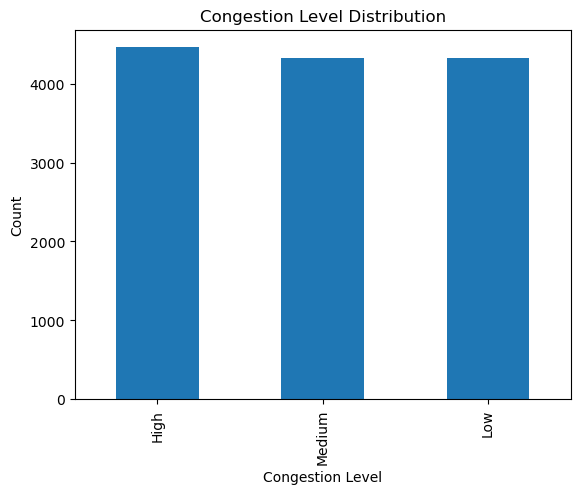

In [41]:
merged_df["congestion_level"].value_counts().plot(kind="bar")
plt.title("Congestion Level Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Count")
plt.show()

The bar chart shows that the three congestion classes—High, Medium, and Low—are almost perfectly balanced, with each category having a very similar number of observations. This is a direct result of using quantile-based labelling, which intentionally divides the data into roughly equal groups.

From a modelling standpoint, this is highly beneficial because it prevents class imbalance, a common issue where models become biased toward the majority class. With balanced classes, the model can learn patterns for each congestion level more effectively, leading to more reliable performance metrics such as accuracy, precision, and recall.

However, from a real-world perspective, this may be slightly artificial, as traffic congestion in practice is often not evenly distributed (e.g., “Low” congestion may occur more frequently than “High”). Despite this, for the purpose of building and evaluating a robust predictive model, this balanced distribution is appropriate and advantageous.

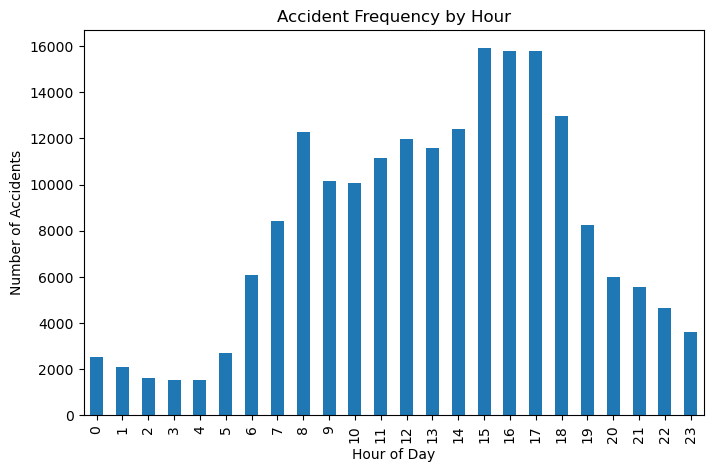

In [43]:
df.groupby("hour").size().plot(kind="bar", figsize=(8, 5))
plt.title("Accident Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

The chart illustrates the distribution of accident frequency across different hours of the day, revealing clear temporal patterns. Accident counts are relatively low during the early morning hours (midnight to around 5 AM), reflecting reduced traffic activity. From 6 AM onwards, there is a noticeable increase, corresponding to the morning commute period. The number of accidents continues to rise throughout the day, peaking during the late afternoon hours (approximately 3 PM to 5 PM), which aligns with evening peak traffic conditions. After this peak, accident frequency gradually declines into the night. Overall, the pattern suggests a strong relationship between traffic volume and accident occurrence, with higher risks during busy commuting periods.

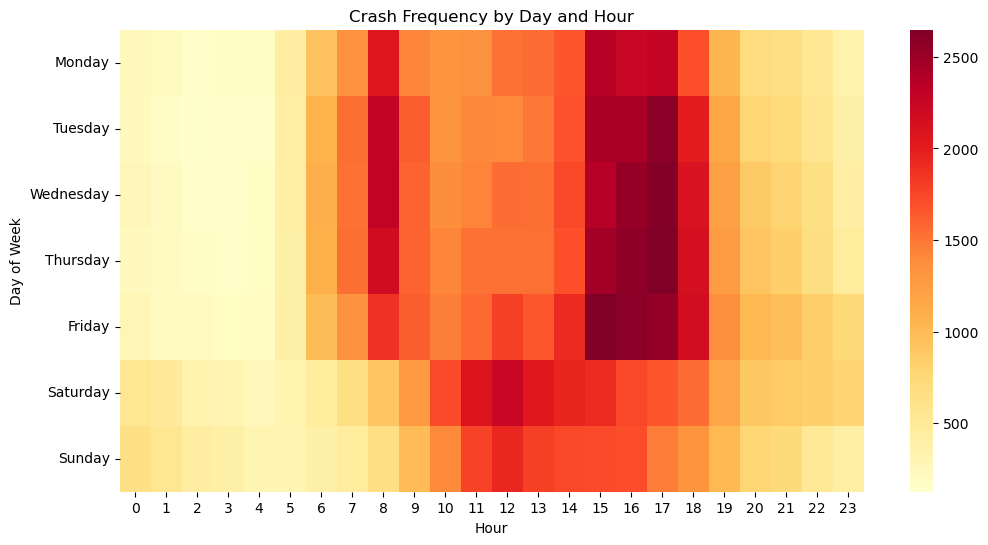

In [45]:
heatmap_data = df.pivot_table(
    index="day_of_week_name",
    columns="hour",
    values="accident_no" if "accident_no" in df.columns else "datetime",
    aggfunc="count"
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False)
plt.title("Crash Frequency by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

### Preprocessing Summary

The preprocessing pipeline was designed to transform raw crash and traffic datasets into a structured and meaningful format suitable for machine learning. Initially, both datasets were cleaned by standardising column names and handling missing values to ensure consistency. For the crash data, date and time fields were converted into a unified datetime format, allowing the extraction of key temporal features such as hour, day of the week, weekend indicators, and peak-hour flags. Similarly, the traffic dataset was processed to derive equivalent temporal features, ensuring alignment between both data sources.

To address the high variability and skewness in the raw traffic counts, the data was aggregated into hourly patterns using mean values across different days. This step significantly reduced noise and extreme fluctuations, producing a more stable representation of typical traffic behaviour. A congestion label (Low, Medium, High) was then created using quantile-based thresholds, ensuring a balanced distribution for model training.

A key challenge solved by this pipeline was the mismatch between crash and traffic datasets in terms of time coverage. Instead of directly merging by timestamp, crash data was aggregated into temporal patterns, enabling a meaningful integration with traffic data. This approach allowed the final dataset to capture both regular traffic trends and accident-related disruption patterns, forming a strong foundation for congestion prediction.

## Models building

### Overview

This modelling pipeline represents a complete and well-structured transition from preprocessed data to predictive insights for the traffic congestion prediction system. First, the dataset is split into features (X) and the target variable (congestion_level), followed by an automatic identification of numerical and categorical variables. A stratified train–test split is applied to preserve the class distribution, which is particularly important for maintaining model reliability across congestion levels. The use of a ColumnTransformer ensures that numerical features are standardised while categorical variables are encoded consistently, creating a clean and unified input for modelling.

Two machine learning models—Logistic Regression and Random Forest—are then implemented within pipelines, allowing preprocessing and training to occur seamlessly without data leakage. Their performances are evaluated using accuracy, classification reports, and confusion matrices, enabling a comprehensive comparison between a linear baseline model and a more complex non-linear ensemble method. Finally, the Random Forest model is further interpreted through feature importance analysis, providing valuable insights into which factors most strongly influence congestion. Overall, this pipeline not only builds predictive models but also ensures robustness, fairness in evaluation, and interpretability, which are essential for a real-world traffic decision-support system.

### Feature–Target Separation and Initial Dataset Inspection

In [52]:
X = merged_df.drop(columns=["congestion_level", "count", "date", "day_of_week_name"], errors="ignore")
y = merged_df["congestion_level"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

print("\nFeatures preview:")
print(X.head())

X shape: (13127, 6)
y shape: (13127,)

Target distribution:
congestion_level
High      4463
Medium    4332
Low       4332
Name: count, dtype: int64

Features preview:
   day_of_week_num  is_weekend  is_peak_hour  avg_accident_count  hour_sin  \
0                0           0             0            0.050796  0.000000   
1                0           0             0            0.045354  0.258819   
2                0           0             0            0.032856  0.500000   
3                0           0             0            0.034469  0.707107   
4                0           0             0            0.036283  0.866025   

   hour_cos  
0  1.000000  
1  0.965926  
2  0.866025  
3  0.707107  
4  0.500000  


In [53]:
print(X.dtypes)

day_of_week_num         int32
is_weekend              int32
is_peak_hour            int32
avg_accident_count    float64
hour_sin              float64
hour_cos              float64
dtype: object


### Identifying Numerical and Categorical Features

In [55]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['day_of_week_num', 'is_weekend', 'is_peak_hour', 'avg_accident_count', 'hour_sin', 'hour_cos']
Categorical features: []


### Train-Test Splitting

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:")
print(y_train.value_counts())
print("y_test:")
print(y_test.value_counts())

X_train: (10501, 6)
X_test : (2626, 6)
y_train:
congestion_level
High      3570
Medium    3466
Low       3465
Name: count, dtype: int64
y_test:
congestion_level
High      893
Low       867
Medium    866
Name: count, dtype: int64


### Building a Preprocessing and Logistic Regression Pipeline

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['day_of_week_num',
                                                   'is_weekend', 'is_peak_hour',
                                                   'avg_accident_count',
                                                   'hour_sin', 'hour_cos']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7440974866717441

Classification Report:

              precision    recall  f1-score   support

        High       0.72      0.63      0.67       893
         Low       0.91      0.94      0.92       867
      Medium       0.61      0.67      0.64       866

    accuracy                           0.74      2626
   macro avg       0.75      0.75      0.74      2626
weighted avg       0.75      0.74      0.74      2626

Confusion Matrix:

[[564   9 320]
 [  5 811  51]
 [218  69 579]]


### Building a Preprocessing and Random Forest Pipeline

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['day_of_week_num',
                                                   'is_weekend', 'is_peak_hour',
                                                   'avg_accident_count',
                                                   'hour_sin', 'hour_cos']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [64]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8274942878903275

Classification Report:

              precision    recall  f1-score   support

        High       0.80      0.81      0.80       893
         Low       0.94      0.93      0.93       867
      Medium       0.74      0.75      0.75       866

    accuracy                           0.83      2626
   macro avg       0.83      0.83      0.83      2626
weighted avg       0.83      0.83      0.83      2626

Confusion Matrix:

[[722   8 163]
 [  3 804  60]
 [178  41 647]]


In [65]:
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", round(log_acc, 4))
print("Random Forest Accuracy:", round(rf_acc, 4))

if rf_acc > log_acc:
    print("Random Forest performed better overall.")
elif log_acc > rf_acc:
    print("Logistic Regression performed better overall.")
else:
    print("Both models performed equally.")

Logistic Regression Accuracy: 0.7441
Random Forest Accuracy: 0.8275
Random Forest performed better overall.


### Random Forest Visualization

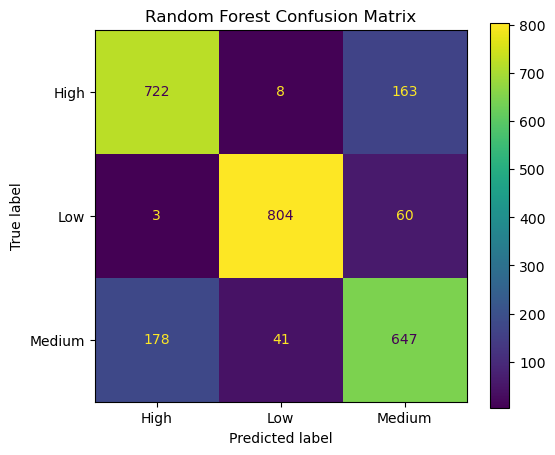

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows that the Random Forest model performs well in classifying traffic congestion levels, with most predictions concentrated along the diagonal, indicating correct classifications. The model achieved strong performance for the “High” and “Low” congestion classes, correctly predicting 722 and 804 instances respectively. However, some confusion can still be observed between the “High” and “Medium” classes, where 163 High cases were predicted as Medium and 178 Medium cases were predicted as High. This suggests that these two congestion levels share similar traffic patterns, making them more difficult to distinguish. Overall, the visualization demonstrates that the Random Forest model is effective and balanced across the three classes, while also highlighting areas where further feature engineering or tuning may improve classification accuracy.

### Random Forest Feature Importance

In [70]:
rf_classifier = rf_model.named_steps["classifier"]

feature_names = numeric_features.copy()

if categorical_features:
    encoded_cat_features = list(
        rf_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
    feature_names += encoded_cat_features

importances = rf_classifier.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values(by="importance", ascending=False)
)

print(feature_importance_df.head(10))

              feature  importance
3  avg_accident_count    0.452434
4            hour_sin    0.244955
5            hour_cos    0.187839
0     day_of_week_num    0.056429
2        is_peak_hour    0.041422
1          is_weekend    0.016920


The feature importance results indicate that avg_accident_count is the most influential variable in predicting traffic congestion levels, contributing approximately 45% of the model’s decision-making power. This suggests that accident frequency has a strong relationship with congestion patterns in the dataset. The cyclical time features, hour_sin and hour_cos, are also highly important, showing that the time of day significantly affects traffic conditions. In contrast, features such as is_weekend and is_peak_hour have lower importance, implying that the Random Forest model can already capture these patterns through the more detailed time-based features. Overall, the visualization highlights that both accident-related information and temporal traffic patterns are key factors in accurately predicting congestion levels.

## Fine-Tuning

### Hyper-parameter Tuning

In [74]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", grid_rf)
])

rf_pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['day_of_week_num',
                                                   'is_weekend', 'is_peak_hour',
                                                   'avg_accident_count',
                                                   'hour_sin', 'hour_cos']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('classifier',
                 GridSearchCV(cv=5,
                              estimator=RandomForestClassifier(random_state=42),
                              n_jobs=-1,
                              param_grid={'max_depth': [None, 10, 20, 30],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [2, 5, 10],
                                          'n_estimators': [100, 200, 300]},
                              scoring='accuracy', verbose=1))])

In [75]:
print("Best parameters:", grid_rf.best_params_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [76]:
y_pred_rf_tuned = rf_pipeline.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned RF Accuracy: 0.8274942878903275
              precision    recall  f1-score   support

        High       0.80      0.81      0.80       893
         Low       0.94      0.93      0.93       867
      Medium       0.74      0.75      0.75       866

    accuracy                           0.83      2626
   macro avg       0.83      0.83      0.83      2626
weighted avg       0.83      0.83      0.83      2626

[[722   8 163]
 [  3 804  60]
 [178  41 647]]


The tuned Random Forest model achieved an accuracy of approximately 82.7%, indicating that the model performs well overall after hyperparameter optimization using GridSearchCV. The best parameters selected were n_estimators = 100, max_depth = None, min_samples_split = 2, and min_samples_leaf = 1, which suggests that the model benefits from a larger ensemble of fully grown decision trees. The classification report also shows strong performance for the “Low” congestion class, with precision and recall values above 0.90, while the “High” and “Medium” classes achieved moderate but balanced results. However, the confusion matrix reveals that the model still struggles to distinguish between “High” and “Medium” congestion levels, as many instances are misclassified between these two categories.


#### The need for Gradient Boosting
Although Random Forest is a powerful ensemble method, it mainly reduces variance by averaging predictions from multiple independent trees. This means it may still miss complex sequential relationships and subtle patterns within the data. Gradient Boosting is introduced to further improve the model because it works differently by building trees sequentially, where each new tree attempts to correct the errors made by previous trees. As a result, Gradient Boosting is often better at handling difficult classification boundaries and capturing more complex nonlinear relationships. In this traffic congestion problem, Gradient Boosting can potentially reduce the confusion between “High” and “Medium” congestion classes, leading to better predictive performance and improved generalisation.

### Gradient Boosting

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.829017517136329
              precision    recall  f1-score   support

        High       0.80      0.82      0.81       893
         Low       0.94      0.93      0.93       867
      Medium       0.75      0.74      0.75       866

    accuracy                           0.83      2626
   macro avg       0.83      0.83      0.83      2626
weighted avg       0.83      0.83      0.83      2626

[[731   8 154]
 [  3 804  60]
 [183  41 642]]


The Gradient Boosting model achieved an accuracy of approximately 82.9%, which is slightly higher than the tuned Random Forest accuracy of 82.7%. Both models performed very well for the “Low” congestion class, achieving precision and recall values above 0.90. However, differences can be seen in the “High” and “Medium” congestion classes. Gradient Boosting slightly improved the recall and F1-score for the “High” class, meaning it was marginally better at identifying severe congestion conditions. On the other hand, the “Medium” class remained difficult for both models, with frequent misclassifications between “High” and “Medium” congestion levels shown in the confusion matrix.

The key difference comes from how the models learn. Random Forest builds many independent trees in parallel and averages their predictions to improve stability and reduce variance. In contrast, Gradient Boosting builds trees sequentially, where each new tree attempts to correct errors made by previous trees. This allows Gradient Boosting to capture more complex patterns and decision boundaries, resulting in slightly better overall predictive performance.

### Fine-tuning Gradient Boosting

In [83]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# 2. Define parameter grid
param_grid_gb = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3],
    "classifier__min_samples_leaf": [1, 2]
}

# 3. GridSearchCV for fine-tuning
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# 4. Train the tuned model
grid_search_gb.fit(X_train, y_train)

# 5. Best parameters and best CV score
print("Best Parameters:")
print(grid_search_gb.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_gb.best_score_)

# 6. Evaluate on test set
best_gb_model = grid_search_gb.best_estimator_

y_pred_gb = best_gb_model.predict(X_test)

print("\nTuned Gradient Boosting Accuracy:")
print(accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

Best Cross-Validation Accuracy:
0.8246824867976701

Tuned Gradient Boosting Accuracy:
0.8301599390708302

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.81      0.81       893
         Low       0.94      0.93      0.93       867
      Medium       0.75      0.75      0.75       866

    accuracy                           0.83      2626
   macro avg       0.83      0.83      0.83      2626
weighted avg       0.83      0.83      0.83      2626


Confusion Matrix:
[[727   8 158]
 [  4 804  59]
 [176  41 649]]


The fine-tuned Gradient Boosting model achieved an accuracy of approximately 83.0%, which is slightly higher than both the original Gradient Boosting and the tuned Random Forest models. The best parameters selected through GridSearchCV were learning_rate = 0.1, max_depth = 2, min_samples_leaf = 1, and n_estimators = 200, indicating that a larger number of shallow trees provided the best balance between learning complex patterns and avoiding overfitting.

The classification report shows balanced performance across all three congestion classes. The “Low” congestion class again achieved the strongest performance with precision and recall values around 0.93–0.94, while the “High” and “Medium” classes achieved F1-scores of 0.81 and 0.75 respectively. Compared to the previous models, the confusion matrix shows a slight reduction in misclassification between the “High” and “Medium” classes. This suggests that fine-tuning helped the model learn more effective decision boundaries and improved its ability to distinguish difficult congestion patterns. Overall, the tuned Gradient Boosting model produced the best and most stable predictive performance among all tested models.

## Ollama's Phi3-mini LLM

In [86]:
# Install required libraries
!pip install ollama

### Setting Up

This code block is responsible for preparing user input into a format suitable for the machine learning congestion prediction model. First, it reconstructs the original hour variable from the cyclical sine and cosine features if the hour column does not already exist in the dataset. The prepare_features() function then converts the user’s selected day and hour into numerical model features, including weekend status, peak-hour status, cyclical hour encoding, and average historical accident counts. These features are organised into a structured DataFrame for prediction. Finally, the get_user_input() function validates the user’s entered day and hour to ensure correct input before passing the information into the prediction pipeline.

In [89]:
import pandas as pd
import numpy as np

# =========================
# Recreate hour column if missing
# =========================

if "hour" not in merged_df.columns:
    merged_df["hour"] = (
        np.arctan2(
            merged_df["hour_sin"],
            merged_df["hour_cos"]
        ) * 24 / (2 * np.pi)
    ) % 24

    merged_df["hour"] = (
        merged_df["hour"]
        .round()
        .astype(int)
    )

def prepare_features(day_of_week, hour, merged_df):
    day_mapping = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4,
        "Saturday": 5, "Sunday": 6
    }

    day_num = day_mapping[day_of_week]
    is_weekend = 1 if day_num >= 5 else 0
    is_peak_hour = 1 if hour in [7, 8, 9, 16, 17, 18] else 0

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    if "avg_accident_count" in merged_df.columns:
        context = merged_df[
            merged_df["day_of_week_num"] == day_num
        ]

        if not context.empty:
            avg_accident_count = context["avg_accident_count"].mean()
        else:
            avg_accident_count = merged_df["avg_accident_count"].mean()
    else:
        avg_accident_count = 0

    input_df = pd.DataFrame([{
        "day_of_week_num": day_num,
        "is_weekend": is_weekend,
        "is_peak_hour": is_peak_hour,
        "avg_accident_count": avg_accident_count,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos
    }])

    return input_df

def get_user_input():
    valid_days = [
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"
    ]

    day_of_week = input("Enter day of week (e.g., Monday): ").strip().title()

    while day_of_week not in valid_days:
        print("Invalid day. Please enter Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, or Sunday.")
        day_of_week = input("Enter day of week: ").strip().title()

    while True:
        try:
            hour = int(input("Enter hour of day (0-23): "))
            if 0 <= hour <= 23:
                break
            else:
                print("Hour must be between 0 and 23.")
        except ValueError:
            print("Please enter a valid number.")

    return day_of_week, hour


### RAG and Prompt Engineering

This code block implements the Retrieval-Augmented Generation (RAG) and prompt engineering components of the traffic congestion prediction pipeline. The retrieve_rag_context() function retrieves historical traffic records with the same day and hour as the user’s query, then summarises the average traffic count and accident count to provide contextual evidence for the prediction. This retrieved information is passed into the generate_prompt_engineered_explanation() function, which constructs a structured prompt for the Ollama Phi-3 Mini large language model. The prompt engineering process guides the LLM to generate a concise academic explanation based only on the machine learning prediction and retrieved historical context, while avoiding unsupported assumptions or exaggerated conclusions.

In [91]:
# =========================
# RAG context retrieval
# =========================

def retrieve_rag_context(day_of_week, hour, merged_df):
    day_mapping = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4,
        "Saturday": 5, "Sunday": 6
    }

    day_num = day_mapping[day_of_week]

    # Recreate hour if needed
    if "hour" not in merged_df.columns:
        merged_df["hour"] = (
            np.arctan2(merged_df["hour_sin"], merged_df["hour_cos"]) * 24 / (2 * np.pi)
        ) % 24
        merged_df["hour"] = merged_df["hour"].round().astype(int)

    similar_records = merged_df[
        (merged_df["day_of_week_num"] == day_num) &
        (merged_df["hour"] == hour)
    ]

    if similar_records.empty:
        return "No similar historical records were found."

    avg_traffic = similar_records["count"].mean()

    avg_crash = (
        similar_records["avg_accident_count"].mean()
        if "avg_accident_count" in similar_records.columns
        else 0
    )

    return f"""
Retrieved context:
- Average traffic count for similar records: {avg_traffic:.2f}
- Average crash count for similar records: {avg_crash:.2f}
"""

# =========================
# Prompt-engineered LLM explanation
# =========================

def generate_prompt_engineered_explanation(
    day_of_week,
    hour,
    prediction,
    probability,
    rag_context
):
    prompt = f"""
You are an academic traffic congestion explanation assistant.

Your task is to explain a machine learning prediction using only the provided model output and retrieved historical context.

Model output:
- Day of week: {day_of_week}
- Time: {hour}:00
- Predicted congestion level: {prediction}
- Model confidence: {probability:.2f}

Retrieved historical context:
{rag_context}

Instructions:
1. Explain why this congestion level may have been predicted.
2. Refer to the retrieved average traffic count.
3. Refer to crash count only if it is greater than 0.
4. Do not invent causes such as weather, events, roadworks, or accidents unless they are provided.
5. Include one practical recommendation for travellers.
6. Write one academic paragraph only.
7. Keep the explanation between 60 and 80 words.

Output:
"""

    response = ollama.chat(
        model="phi3:mini",
        messages=[
            {"role": "user", "content": prompt}
        ],
        options={
            "temperature": 0.5,
            "num_predict": 150
        }
    )

    return response["message"]["content"]

### Full Prediction Pipeline

This code block represents the final execution stage of the traffic congestion prediction pipeline. First, the system collects the user’s selected day and hour as input. The input is then transformed into machine learning features using the feature preparation function before being passed into the trained Gradient Boosting model to generate a congestion prediction and confidence score. Next, the Retrieval-Augmented Generation (RAG) component retrieves similar historical traffic records to provide contextual information, including average traffic and accident counts. Finally, the prompt-engineered Ollama Phi-3 Mini model uses both the prediction output and retrieved context to generate a concise natural language explanation and practical travel recommendation for the user.

In [93]:
import ollama

day_of_week, hour = get_user_input()

input_df = prepare_features(day_of_week, hour, merged_df)

prediction = best_gb_model.predict(input_df)[0]

probability = best_gb_model.predict_proba(input_df).max()

rag_context = retrieve_rag_context(day_of_week, hour, merged_df)

explanation = generate_prompt_engineered_explanation(
    day_of_week=day_of_week,
    hour=hour,
    prediction=prediction,
    probability=probability,
    rag_context=rag_context
)

print("Predicted congestion level:", prediction)
print("Model confidence:", round(probability, 2))
print()
print(explanation)

Enter day of week (e.g., Monday):  Friday
Enter hour of day (0-23):  18


Predicted congestion level: High
Model confidence: 0.74

The high congestion prediction on Friday at 18:00 likely stems from increased commuter traffic, coinciding with a higher-than-average count of vehicles (20.11) observed in similar historical instances without any reported accidents or roadworks to exacerbate the situation. Given this model's confidence level is substantial at 74%, travelers might consider departing earlier or opting for alternative routes during peak hours, thereby mitigating potential delays while adhering to safe driving practices within a traffic-congested environment.


The results demonstrate that the proposed Gradient Boosting, RAG, and prompt-engineered LLM pipeline is capable of generating interpretable and context-aware traffic congestion predictions with relatively strong confidence. A major strength of the model is its ability to combine machine learning predictions with historical traffic context to produce human-readable explanations and practical recommendations. However, the generated explanation still occasionally includes inferred assumptions, such as commuting behaviour, despite not being explicitly present in the retrieved data. In addition, the RAG component currently relies on limited structured historical records rather than richer external data sources. Future improvements could include integrating real-time weather, event, and road incident data, enhancing retrieval granularity, and further refining prompt engineering to reduce unsupported reasoning and improve factual grounding.

## Conclusion 

Overall, the developed pipeline successfully fulfilled the project objectives by creating an intelligent and explainable traffic congestion prediction system. The machine learning component effectively predicted congestion levels using engineered temporal and crash-related features, while the integration of LLMs addressed the requirement of generating understandable explanations for end users. Furthermore, the implementation of prompt engineering and RAG demonstrated the optimization techniques expected for higher-level performance, as they improved contextual reasoning and explanation quality beyond traditional static systems. The project also showed the value of combining predictive analytics with generative AI to support smarter traffic management decisions. Although the current system achieved promising results, future improvements could include integrating real-time traffic APIs, weather data, and live event information to further enhance prediction accuracy, scalability, and practical deployment in smart city environments.